In [2]:
import pandas as pd

# Cargar datasets
natalidad = pd.read_csv(r"C:\Users\yanin\OneDrive\Desktop\Proyecto Evolución de la Salud Materno-Infantil en Argentina\tasa-natalidad-deis-2000-2023 (1).csv")
mortalidad_fetal = pd.read_csv(r"C:\Users\yanin\OneDrive\Desktop\Proyecto Evolución de la Salud Materno-Infantil en Argentina\tasa-mortalidad-fetal-total-deis-2006-2023 (1).csv")
mortalidad_infantil = pd.read_csv(r"C:\Users\yanin\OneDrive\Desktop\Proyecto Evolución de la Salud Materno-Infantil en Argentina\tasa-mortalidad-infantil-deis-1990-2023 (1).csv")
# Ver primeras filas
print(natalidad.head())
print(mortalidad_fetal.head())
print(mortalidad_infantil.head())


  indice_tiempo  natalidad_argentina  \
0    2000-01-01                 19.0   
1    2001-01-01                 18.2   
2    2002-01-01                 18.3   
3    2003-01-01                 18.4   
4    2004-01-01                 19.3   

   natalidad_ciudad_autonoma_de_buenos_aires  natalidad_buenos_aires  \
0                                       14.3                    17.5   
1                                       13.9                    16.9   
2                                       13.6                    17.0   
3                                       14.2                    17.3   
4                                       14.9                    18.5   

   natalidad_catamarca  natalidad_cordoba  natalidad_corrientes  \
0                 25.8               17.2                  22.7   
1                 24.9               15.9                  21.9   
2                 24.4               16.6                  23.3   
3                 22.5               17.5                 

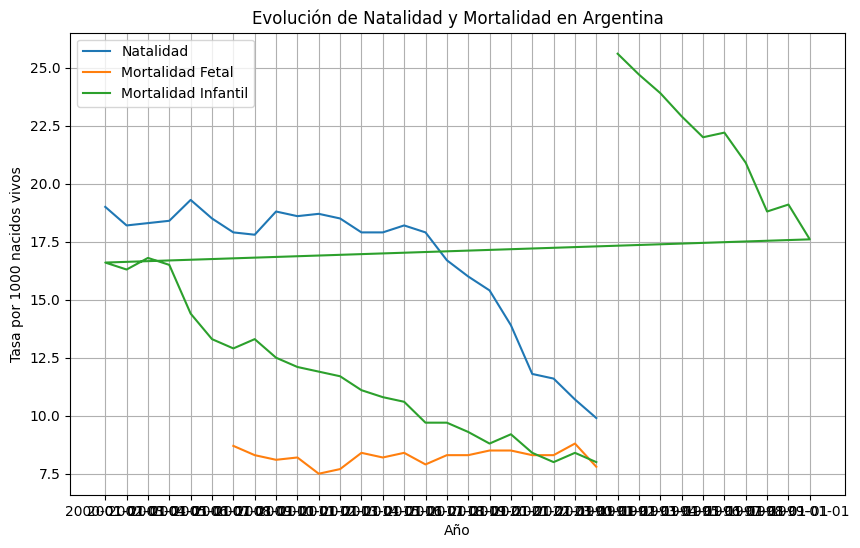

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(natalidad["indice_tiempo"], natalidad["natalidad_argentina"], label="Natalidad")
plt.plot(mortalidad_fetal["indice_tiempo"], mortalidad_fetal["mortalidad_fetal_total_argentina"], label="Mortalidad Fetal")
plt.plot(mortalidad_infantil["indice_tiempo"], mortalidad_infantil["mortalidad_infantil_argentina"], label="Mortalidad Infantil")

plt.title("Evolución de Natalidad y Mortalidad en Argentina")
plt.xlabel("Año")
plt.ylabel("Tasa por 1000 nacidos vivos")
plt.legend()
plt.grid(True)
plt.show()


,anio,Mortalidad Infantil (por 1.000 NV),Natalidad (por 1.000 hab),Mortalidad Fetal (por 1.000 NV)
0,1990,25.6,NaN,NaN
1,1991,24.7,NaN,NaN
2,1992,23.9,NaN,NaN
3,1993,22.9,NaN,NaN
4,1994,22.0,NaN,NaN
5,1995,22.2,NaN,NaN
6,1996,20.9,NaN,NaN
7,1997,18.8,NaN,NaN
8,1998,19.1,NaN,NaN
9,1999,17.6,NaN,NaN


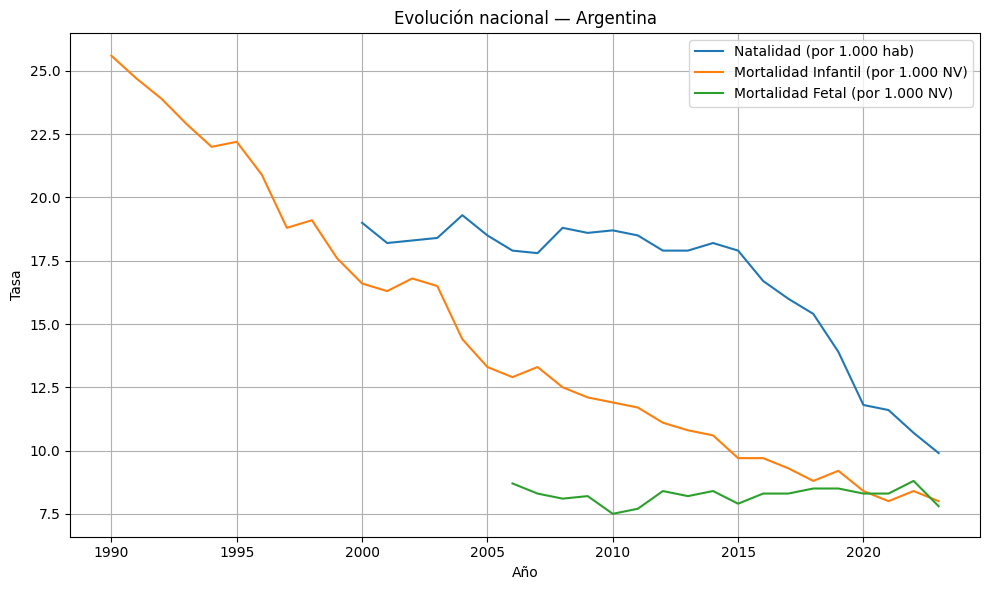

,indicador,anio_inicial,valor_inicial,anio_final,valor_final,cambio_abs,cambio_pct,CAGR_pct,anio_min,valor_min,anio_max,valor_max
0,Natalidad (por 1.000 hab),2000,19.0,2023,9.9,-9.1,-47.89,-2.79,2023,9.9,2004,19.3
1,Mortalidad Infantil (por 1.000 NV),1990,25.6,2023,8.0,-17.6,-68.75,-3.46,2021,8.0,1990,25.6
2,Mortalidad Fetal (por 1.000 NV),2006,8.7,2023,7.8,-0.9,-10.34,-0.64,2010,7.5,2022,8.8


In [4]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) RUTAS (editá si guardaste en otro lugar)
PATH_NATALIDAD = r"C:\Users\yanin\OneDrive\Desktop\Proyecto Evolución de la Salud Materno-Infantil en Argentina\tasa-natalidad-deis-2000-2023 (1).csv"
PATH_MFETAL    = r"C:\Users\yanin\OneDrive\Desktop\Proyecto Evolución de la Salud Materno-Infantil en Argentina\tasa-mortalidad-fetal-total-deis-2006-2023 (1).csv"
PATH_MINFANTIL = r"C:\Users\yanin\OneDrive\Desktop\Proyecto Evolución de la Salud Materno-Infantil en Argentina\tasa-mortalidad-infantil-deis-1990-2023 (1).csv"

# 2) CARGA
natalidad = pd.read_csv(PATH_NATALIDAD, parse_dates=["indice_tiempo"])
mortalidad_fetal = pd.read_csv(PATH_MFETAL, parse_dates=["indice_tiempo"])
mortalidad_infantil = pd.read_csv(PATH_MINFANTIL, parse_dates=["indice_tiempo"])

# 3) SERIES NACIONALES
df_nat = natalidad[["indice_tiempo","natalidad_argentina"]].copy()
df_nat["anio"] = df_nat["indice_tiempo"].dt.year
df_nat = df_nat[["anio","natalidad_argentina"]]

df_mf = mortalidad_fetal[["indice_tiempo","mortalidad_fetal_total_argentina"]].copy()
df_mf["anio"] = df_mf["indice_tiempo"].dt.year
df_mf = df_mf[["anio","mortalidad_fetal_total_argentina"]]

df_mi = mortalidad_infantil[["indice_tiempo","mortalidad_infantil_argentina"]].copy()
df_mi["anio"] = df_mi["indice_tiempo"].dt.year
df_mi = df_mi[["anio","mortalidad_infantil_argentina"]]

series = (
    df_mi.merge(df_nat, on="anio", how="outer")
         .merge(df_mf, on="anio", how="outer")
         .sort_values("anio")
         .reset_index(drop=True)
)

series = series.rename(columns={
    "mortalidad_infantil_argentina": "Mortalidad Infantil (por 1.000 NV)",
    "natalidad_argentina": "Natalidad (por 1.000 hab)",
    "mortalidad_fetal_total_argentina": "Mortalidad Fetal (por 1.000 NV)",
})

# 4) VISTA RÁPIDA
display(series.head(15))

# 5) GRÁFICO
plt.figure(figsize=(10,6))
for col in ["Natalidad (por 1.000 hab)",
            "Mortalidad Infantil (por 1.000 NV)",
            "Mortalidad Fetal (por 1.000 NV)"]:
    plt.plot(series["anio"], series[col], label=col)
plt.title("Evolución nacional — Argentina")
plt.xlabel("Año")
plt.ylabel("Tasa")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6) RESUMEN DE INDICADORES
def resumen_indicador(df, col):
    tmp = df[["anio", col]].dropna().sort_values("anio")
    if tmp.empty or len(tmp) == 1:
        return None
    a0, v0 = int(tmp.iloc[0]["anio"]), float(tmp.iloc[0][col])
    a1, v1 = int(tmp.iloc[-1]["anio"]), float(tmp.iloc[-1][col])
    cambio_abs = v1 - v0
    cambio_pct = (v1 / v0 - 1) * 100 if v0 != 0 else np.nan
    anios = a1 - a0
    CAGR = ((v1 / v0)**(1/anios) - 1) * 100 if (v0 > 0 and anios > 0) else np.nan
    idx_min = tmp[col].idxmin(); idx_max = tmp[col].idxmax()
    return {
        "indicador": col,
        "anio_inicial": a0,
        "valor_inicial": round(v0,2),
        "anio_final": a1,
        "valor_final": round(v1,2),
        "cambio_abs": round(cambio_abs,2),
        "cambio_pct": round(cambio_pct,2),
        "CAGR_pct": round(CAGR,2),
        "anio_min": int(tmp.loc[idx_min, "anio"]),
        "valor_min": round(float(tmp.loc[idx_min, col]),2),
        "anio_max": int(tmp.loc[idx_max, "anio"]),
        "valor_max": round(float(tmp.loc[idx_max, col]),2),
    }

cols = ["Natalidad (por 1.000 hab)", "Mortalidad Infantil (por 1.000 NV)", "Mortalidad Fetal (por 1.000 NV)"]
resumen = pd.DataFrame([resumen_indicador(series, c) for c in cols if resumen_indicador(series, c) is not None])
display(resumen)

# 7) (Opcional) GUARDAR RESULTADOS EN CSV AL LADO DE TU NOTEBOOK
# series.to_csv("series_nacionales_argentina.csv", index=False, encoding="utf-8")
# resumen.to_csv("resumen_indicadores.csv", index=False, encoding="utf-8")


In [5]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np



# --- Helpers ---
def year(df, y):
    df = df.copy()
    df["anio"] = df["indice_tiempo"].dt.year
    return df[df["anio"] == y].iloc[0:1]  # la fila del año

def melt_provincias(row_df, prefix, total_col):
    cols = [c for c in row_df.columns if c.startswith(prefix) and c != total_col]
    long = row_df[cols].T.reset_index()
    long.columns = ["col", "valor"]
    long["provincia"] = long["col"].str.replace(prefix, "", regex=False)
    long["provincia"] = long["provincia"].str.replace("_", " ").str.strip()
    # Normalizar nombres (mejorá si lo necesitás)
    fixes = {
        "ciudad autonoma de buenos aires": "Ciudad Autónoma de Buenos Aires",
        "buenos aires": "Buenos Aires",
        "santiago del estero": "Santiago del Estero",
        "tierra del fuego": "Tierra del Fuego",
        "rio negro": "Río Negro",
        "neuquen": "Neuquén",
        "cordoba": "Córdoba",
        "la pampa": "La Pampa",
        "la rioja": "La Rioja",
        "san juan": "San Juan",
        "san luis": "San Luis",
        "santa fe": "Santa Fe",
        "santa cruz": "Santa Cruz",
        "entre rios": "Entre Ríos",
    }
    long["provincia"] = long["provincia"].str.lower().map(lambda x: fixes.get(x, x.title()))
    return long[["provincia", "valor"]].sort_values("valor", ascending=False).reset_index(drop=True)

def top_bottom(df_long, k=5, asc=False):
    df_sorted = df_long.sort_values("valor", ascending=asc).reset_index(drop=True)
    top = df_sorted.head(k).copy()
    bottom = df_sorted.tail(k).copy().sort_values("valor", ascending=asc).reset_index(drop=True)
    return top, bottom

# --- Año de análisis ---
ANIO = 2023

# --- Natalidad 2023 (por 1.000 hab) ---
row_nat = year(natalidad, ANIO)
nat_2023 = melt_provincias(row_nat, prefix="natalidad_", total_col="natalidad_argentina")
nat_top5, nat_bottom5 = top_bottom(nat_2023, k=5, asc=False)

# --- Mortalidad Infantil 2023 (por 1.000 NV) ---
row_mi = year(mortalidad_infantil, ANIO)
mi_2023 = melt_provincias(row_mi, prefix="mortalidad_infantil_", total_col="mortalidad_infantil_argentina")
mi_top5, mi_bottom5 = top_bottom(mi_2023, k=5, asc=False)

# --- Mortalidad Fetal 2023 (por 1.000 NV) ---
row_mf = year(mortalidad_fetal, ANIO)
mf_2023 = melt_provincias(row_mf, prefix="mortalidad_fetal_total_", total_col="mortalidad_fetal_total_argentina")
mf_top5, mf_bottom5 = top_bottom(mf_2023, k=5, asc=False)

# --- Mostrar resultados ---
print(f"► NATALIDAD {ANIO} (mayores tasas)")
display(nat_top5)
print(f"► NATALIDAD {ANIO} (menores tasas)")
display(nat_bottom5)

print(f"\n► MORTALIDAD INFANTIL {ANIO} (mayores tasas)")
display(mi_top5)
print(f"► MORTALIDAD INFANTIL {ANIO} (menores tasas)")
display(mi_bottom5)

print(f"\n► MORTALIDAD FETAL {ANIO} (mayores tasas)")
display(mf_top5)
print(f"► MORTALIDAD FETAL {ANIO} (menores tasas)")
display(mf_bottom5)


► NATALIDAD 2023 (mayores tasas)


,provincia,valor
0,Misiones,14.5
1,Chaco,13.5
2,Formosa,13.3
3,Corrientes,12.4
4,San Juan,12.2


► NATALIDAD 2023 (menores tasas)


,provincia,valor
0,La Pampa,8.8
1,Chubut,8.4
2,Santa Cruz,8.0
3,Ciudad Autónoma de Buenos Aires,7.8
4,Tierra del Fuego,7.7



► MORTALIDAD INFANTIL 2023 (mayores tasas)


...

,provincia,valor
0,Neuquén,7.0
1,Sanluis,6.0
2,Mendoza,5.8
3,Caba,5.5
4,Chubut,5.2



► MORTALIDAD FETAL 2023 (mayores tasas)


,provincia,valor
0,Tucuman,13.1
1,Corrientes,11.3
2,Formosa,10.8
3,Salta,9.7
4,Entrerios,8.8


► MORTALIDAD FETAL 2023 (menores tasas)


,provincia,valor
0,Lapampa,5.5
1,Tierradelfuego,4.8
2,Santacruz,4.4
3,Caba,4.3
4,Santiagodelestero,3.2


NameError: name 'fig_nat' is not defined

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import plotly.express as px

# --- 1) Asegurate de tener cargados estos DataFrames desde antes ---
# natalidad = pd.read_csv(PATH_NATALIDAD, parse_dates=["indice_tiempo"])
# mortalidad_fetal = pd.read_csv(PATH_MFETAL, parse_dates=["indice_tiempo"])
# mortalidad_infantil = pd.read_csv(PATH_MINFANTIL, parse_dates=["indice_tiempo"])

ANIO = 2023

# Helpers
def year(df, y):
    df = df.copy()
    df["anio"] = df["indice_tiempo"].dt.year
    return df[df["anio"] == y].iloc[0:1]  # fila del año

def melt_provincias(row_df, prefix, total_col):
    cols = [c for c in row_df.columns if c.startswith(prefix) and c != total_col]
    long = row_df[cols].T.reset_index()
    long.columns = ["col", "valor"]
    long["provincia"] = long["col"].str.replace(prefix, "", regex=False)
    long["provincia"] = long["provincia"].str.replace("_", " ").str.strip()
    # Normalización de nombres -> deben coincidir con el GeoJSON
    fixes = {
        "ciudad autonoma de buenos aires": "Ciudad Autónoma de Buenos Aires",
        "buenos aires": "Buenos Aires",
        "santiago del estero": "Santiago del Estero",
        "tierra del fuego": "Tierra del Fuego",
        "rio negro": "Río Negro",
        "neuquen": "Neuquén",
        "cordoba": "Córdoba",
        "la pampa": "La Pampa",
        "la rioja": "La Rioja",
        "san juan": "San Juan",
        "san luis": "San Luis",
        "santa fe": "Santa Fe",
        "santa cruz": "Santa Cruz",
        "entre rios": "Entre Ríos",
    }
    long["provincia"] = long["provincia"].str.lower().map(lambda x: fixes.get(x, x.title()))
    return long[["provincia", "valor"]].sort_values("valor", ascending=False).reset_index(drop=True)

# --- 2) Armar dataframes 2023 por indicador ---
row_nat = year(natalidad, ANIO)
nat_2023 = melt_provincias(row_nat, prefix="natalidad_", total_col="natalidad_argentina")

row_mi = year(mortalidad_infantil, ANIO)
mi_2023 = melt_provincias(row_mi, prefix="mortalidad_infantil_", total_col="mortalidad_infantil_argentina")

row_mf = year(mortalidad_fetal, ANIO)
mf_2023 = melt_provincias(row_mf, prefix="mortalidad_fetal_total_", total_col="mortalidad_fetal_total_argentina")

# --- 3) Fuente GeoJSON (pública) con provincias de Argentina ---
GEOJSON_URL = "https://raw.githubusercontent.com/deldersveld/topojson/master/countries/argentina/argentina-provinces.json"
FEATURE_KEY = "properties.name"  # clave de nombre dentro del geojson

# --- 4) Función para mapear con Plotly ---
def mapa_provincias(df, titulo):
    fig = px.choropleth(
        df,
        geojson=GEOJSON_URL,
        featureidkey=FEATURE_KEY,
        locations="provincia",
        color="valor",
        hover_name="provincia",
        color_continuous_scale="YlOrRd",
        title=titulo,
    )
    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(margin=dict(l=0, r=0, t=60, b=0))
    return fig

# --- 5) Generar y mostrar mapas ---
fig_nat = mapa_provincias(nat_2023, f"Natalidad por provincia — {ANIO} (por 1.000 hab)")
fig_mi  = mapa_provincias(mi_2023,  f"Mortalidad infantil por provincia — {ANIO} (por 1.000 NV)")
fig_mf  = mapa_provincias(mf_2023,  f"Mortalidad fetal por provincia — {ANIO} (por 1.000 NV)")

fig_nat.show()
fig_mi.show()
fig_mf.show()

# --- 6) Exportar a HTML (quedan en la carpeta del notebook) ---
fig_nat.write_html(f"mapa_natalidad_{ANIO}.html")
fig_mi.write_html(f"mapa_mortalidad_infantil_{ANIO}.html")
fig_mf.write_html(f"mapa_mortalidad_fetal_{ANIO}.html")

print("Archivos HTML generados:")
print(f"- mapa_natalidad_{ANIO}.html")
print(f"- mapa_mortalidad_infantil_{ANIO}.html")
print(f"- mapa_mortalidad_fetal_{ANIO}.html")


Archivos HTML generados:
- mapa_natalidad_2023.html
- mapa_mortalidad_infantil_2023.html
- mapa_mortalidad_fetal_2023.html


In [9]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio

# ---------------------------------------------------------------------
# Asegurate de tener cargados estos DataFrames (con parse_dates)
# natalidad = pd.read_csv(PATH_NATALIDAD, parse_dates=["indice_tiempo"])
# mortalidad_fetal = pd.read_csv(PATH_MFETAL, parse_dates=["indice_tiempo"])
# mortalidad_infantil = pd.read_csv(PATH_MINFANTIL, parse_dates=["indice_tiempo"])
# ---------------------------------------------------------------------

ANIO = 2023

# --- Helpers ---
def year(df, y):
    df = df.copy()
    df["anio"] = df["indice_tiempo"].dt.year
    # Tomar la fila del año (los CSV traen 1 fila por año)
    out = df[df["anio"] == y]
    if out.empty:
        raise ValueError(f"No hay datos para el año {y} en este dataset.")
    return out.iloc[0:1]

def melt_provincias(row_df, prefix, total_col):
    cols = [c for c in row_df.columns if c.startswith(prefix) and c != total_col]
    long = row_df[cols].T.reset_index()
    long.columns = ["col", "valor"]
    long["provincia"] = long["col"].str.replace(prefix, "", regex=False)
    long["provincia"] = long["provincia"].str.replace("_", " ").str.strip()

    # Normalización de nombres (para coincidir con el GeoJSON)
    fixes = {
        "ciudad autonoma de buenos aires": "Ciudad Autónoma de Buenos Aires",
        "buenos aires": "Buenos Aires",
        "santiago del estero": "Santiago del Estero",
        "tierra del fuego": "Tierra del Fuego",
        "rio negro": "Río Negro",
        "neuquen": "Neuquén",
        "cordoba": "Córdoba",
        "la pampa": "La Pampa",
        "la rioja": "La Rioja",
        "san juan": "San Juan",
        "san luis": "San Luis",
        "santa fe": "Santa Fe",
        "santa cruz": "Santa Cruz",
        "entre rios": "Entre Ríos",
    }
    long["provincia"] = long["provincia"].str.lower().map(lambda x: fixes.get(x, x.title()))
    return long[["provincia", "valor"]].sort_values("valor", ascending=False).reset_index(drop=True)

def top_bottom(df_long, k=5):
    top = df_long.sort_values("valor", ascending=False).head(k).reset_index(drop=True)
    bottom = df_long.sort_values("valor", ascending=True).head(k).reset_index(drop=True)
    return top, bottom

# --- Construir dataframes 2023 por indicador ---
row_nat = year(natalidad, ANIO)
nat_2023 = melt_provincias(row_nat, prefix="natalidad_", total_col="natalidad_argentina")

row_mi = year(mortalidad_infantil, ANIO)
mi_2023 = melt_provincias(row_mi, prefix="mortalidad_infantil_", total_col="mortalidad_infantil_argentina")

row_mf = year(mortalidad_fetal, ANIO)
mf_2023 = melt_provincias(row_mf, prefix="mortalidad_fetal_total_", total_col="mortalidad_fetal_total_argentina")

# --- Rankings top/bottom 5 ---
nat_top5, nat_bottom5 = top_bottom(nat_2023, k=5)
mi_top5,  mi_bottom5  = top_bottom(mi_2023,  k=5)
mf_top5,  mf_bottom5  = top_bottom(mf_2023,  k=5)

# --- Choropleths con Plotly ---
GEOJSON_URL = "https://raw.githubusercontent.com/deldersveld/topojson/master/countries/argentina/argentina-provinces.json"
FEATURE_KEY = "properties.name"

def mapa_provincias(df, titulo):
    fig = px.choropleth(
        df,
        geojson=GEOJSON_URL,
        featureidkey=FEATURE_KEY,
        locations="provincia",
        color="valor",
        hover_name="provincia",
        color_continuous_scale="YlOrRd",
        title=titulo,
    )
    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(margin=dict(l=0, r=0, t=60, b=0))
    return fig

# Mostrar en navegador por defecto
pio.renderers.default = "browser"

fig_nat = mapa_provincias(nat_2023, f"Natalidad por provincia — {ANIO} (por 1.000 hab)")
fig_mi  = mapa_provincias(mi_2023,  f"Mortalidad infantil por provincia — {ANIO} (por 1.000 NV)")
fig_mf  = mapa_provincias(mf_2023,  f"Mortalidad fetal por provincia — {ANIO} (por 1.000 NV)")

fig_nat.show()
fig_mi.show()
fig_mf.show()

# --- Exportar mapas a HTML ---
fig_nat.write_html(f"mapa_natalidad_{ANIO}.html")
fig_mi.write_html(f"mapa_mortalidad_infantil_{ANIO}.html")
fig_mf.write_html(f"mapa_mortalidad_fetal_{ANIO}.html")

# --- Exportar rankings y tablas completas a Excel ---
with pd.ExcelWriter(f"rankings_provincias_{ANIO}.xlsx") as writer:
    nat_top5.to_excel(writer, sheet_name="Natalidad_top5", index=False)
    nat_bottom5.to_excel(writer, sheet_name="Natalidad_bottom5", index=False)
    nat_2023.sort_values("valor", ascending=False).to_excel(writer, sheet_name="Natalidad_todas", index=False)

    mi_top5.to_excel(writer, sheet_name="MI_top5", index=False)
    mi_bottom5.to_excel(writer, sheet_name="MI_bottom5", index=False)
    mi_2023.sort_values("valor", ascending=False).to_excel(writer, sheet_name="MI_todas", index=False)

    mf_top5.to_excel(writer, sheet_name="MF_top5", index=False)
    mf_bottom5.to_excel(writer, sheet_name="MF_bottom5", index=False)
    mf_2023.sort_values("valor", ascending=False).to_excel(writer, sheet_name="MF_todas", index=False)

print("Listo ✅")
print(f"- HTML: mapa_natalidad_{ANIO}.html | mapa_mortalidad_infantil_{ANIO}.html | mapa_mortalidad_fetal_{ANIO}.html")
print(f"- Excel: rankings_provincias_{ANIO}.xlsx")


ModuleNotFoundError: No module named 'openpyxl'

In [ ]:
import plotly.io as pio
pio.renderers.default = "browser"   # abre en tu navegador por defecto

fig_nat.show()
fig_mi.show()
fig_mf.show()

NameError: name 'fig_nat' is not defined